# Cell 1 - Import & Load

In [4]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv(
    "/kaggle/input/datasets/mashlyn/online-retail-ii-uci/online_retail_II.csv",
    encoding="utf-8-sig"
)

print("=== SHAPE ===")
print(df.shape)

print("\n=== COLUMNS & DTYPES ===")
print(df.dtypes)

print("\n=== FIRST 5 ROWS ===")
print(df.head())

print("\n=== NULL COUNT ===")
print(df.isnull().sum())

=== SHAPE ===
(1067371, 8)

=== COLUMNS & DTYPES ===
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

=== FIRST 5 ROWS ===
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4

## Initial Data Inspection

Dataset gồm **1,067,371 dòng** và **8 cột**, covering giao dịch bán lẻ online.

### Quan sát chính:

**Cấu trúc cột:**
- `Invoice`: mã đơn hàng - dạng object, cần check cancelled (prefix 'C')
- `InvoiceDate`: đang là object - cần parse sang datetime
- `Customer ID`: float64 - bất thường, do pandas đọc cột có null thành float
- `Price`, `Quantity`: numeric - cần kiểm tra giá trị âm / bằng 0

**Vấn đề null:**
- `Customer ID` null **243,007 rows (~22.8%)** - đây là vấn đề lớn nhất.
Đóng vai trò là **định danh khách hàng (identifier)**, không phải feature.
Row nào thiếu Customer ID đồng nghĩa giao dịch đó không gắn được với bất kỳ
customer cụ thể nào → không thể dùng cho customer-level aggregation.
Toàn bộ 243,007 rows này sẽ bị **loại khỏi pipeline** ở bước cleaning.
- `Description` null **4,382 rows (~0.4%)** - ít, không ảnh hưởng đáng kể.

**Nhận xét:**
> 22.8% transactions không có Customer ID - tức gần 1/4 doanh thu
> có thể đến từ khách vãng lai (guest checkout), không track được.
> Đây là điểm cần ghi chú trong business context,
> không phải data quality issue thuần túy.

# Cell 2 - Deeper Inspection

In [5]:
print("=== INVOICE - sample cancelled ===")
cancelled = df[df["Invoice"].astype(str).str.startswith("C")]
print(f"Cancelled invoices: {len(cancelled):,}")
print(cancelled.head(3))

print("\n=== QUANTITY - distribution ===")
print(df["Quantity"].describe())
print(f"Quantity <= 0: {(df['Quantity'] <= 0).sum():,}")

print("\n=== PRICE - distribution ===")
print(df["Price"].describe())
print(f"Price <= 0: {(df['Price'] <= 0).sum():,}")

print("\n=== COUNTRY - top 10 ===")
print(df["Country"].value_counts().head(10))

=== INVOICE — sample cancelled ===
Cancelled invoices: 19,494
     Invoice StockCode                    Description  Quantity  \
178  C489449     22087       PAPER BUNTING WHITE LACE       -12   
179  C489449    85206A   CREAM FELT EASTER EGG BASKET        -6   
180  C489449     21895  POTTING SHED SOW 'N' GROW SET        -4   

             InvoiceDate  Price  Customer ID    Country  
178  2009-12-01 10:33:00   2.95      16321.0  Australia  
179  2009-12-01 10:33:00   1.65      16321.0  Australia  
180  2009-12-01 10:33:00   4.25      16321.0  Australia  

=== QUANTITY — distribution ===
count    1.067371e+06
mean     9.938898e+00
std      1.727058e+02
min     -8.099500e+04
25%      1.000000e+00
50%      3.000000e+00
75%      1.000000e+01
max      8.099500e+04
Name: Quantity, dtype: float64
Quantity <= 0: 22,950

=== PRICE — distribution ===
count    1.067371e+06
mean     4.649388e+00
std      1.235531e+02
min     -5.359436e+04
25%      1.250000e+00
50%      2.100000e+00
75%      4.15

## Deep Inspection - Anomalies & Distribution

### 1. Cancelled Invoices
Có **19,494 rows** có Invoice bắt đầu bằng `'C'` đây là các đơn hàng bị huỷ.
Quan sát thấy `Quantity` của những row này đều **âm** (ví dụ: -12, -6, -4),
phản ánh việc hoàn trả hàng. Những row này sẽ bị loại khỏi pipeline
vì không đại diện cho hành vi mua hàng thực sự.

### 2. Quantity
- Min = **-80,995** - giá trị âm cực lớn, khả năng cao là bulk return hoặc data entry error
- 75% giao dịch có Quantity ≤ 10 → phần lớn là đơn lẻ, nhỏ
- **22,950 rows** có Quantity ≤ 0 → sẽ bị drop (bao gồm cả cancelled ở trên)

### 3. Price
- Min = **-53,594** - giá âm bất thường, có thể là điều chỉnh kế toán hoặc lỗi nhập
- Median = £2.10, mean = £4.65 → distribution lệch phải (long-tail)
- **6,207 rows** có Price ≤ 0 → sẽ bị drop

### 4. Country
- **United Kingdom chiếm 91.9%** tổng giao dịch - dataset này chủ yếu là UK market
- Phần còn lại trải rộng trên nhiều nước châu Âu (EIRE, Germany, France...)
- Không cần filter theo country, nhưng nên ghi nhận UK dominance
  khi interpret kết quả segmentation sau này

### Cleaning Plan
| Vấn đề | Action |
|---|---|
| `Customer ID` null (243,007) | Drop |
| Cancelled invoices - prefix 'C' (19,494) | Drop |
| `Quantity` ≤ 0 (22,950) | Drop |
| `Price` ≤ 0 (6,207) | Drop |
| `InvoiceDate` là object | Parse sang datetime |
| `Customer ID` là float | Convert sang string |

# Cell 3 - Data Cleaning Pipeline


In [6]:
df_clean = df.copy()

# 1. Parse datetime
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

# 2. Drop null Customer ID
before = len(df_clean)
df_clean = df_clean.dropna(subset=["Customer ID"])
print(f"Drop null Customer ID: -{before - len(df_clean):,} rows")

# 3. Drop cancelled invoices
before = len(df_clean)
df_clean = df_clean[~df_clean["Invoice"].astype(str).str.startswith("C")]
print(f"Drop cancelled invoices: -{before - len(df_clean):,} rows")

# 4. Drop Quantity <= 0
before = len(df_clean)
df_clean = df_clean[df_clean["Quantity"] > 0]
print(f"Drop Quantity <= 0: -{before - len(df_clean):,} rows")

# 5. Drop Price <= 0
before = len(df_clean)
df_clean = df_clean[df_clean["Price"] > 0]
print(f"Drop Price <= 0: -{before - len(df_clean):,} rows")

# 6. Convert Customer ID float → string
df_clean["Customer ID"] = df_clean["Customer ID"].astype(int).astype(str)

# 7. Tạo total_price
df_clean["total_price"] = df_clean["Quantity"] * df_clean["Price"]

# Summary
print(f"\n=== AFTER CLEANING ===")
print(f"Rows remaining : {len(df_clean):,}")
print(f"Rows removed   : {len(df) - len(df_clean):,} ({(1 - len(df_clean)/len(df))*100:.1f}%)")
print(f"Unique customers: {df_clean['Customer ID'].nunique():,}")
print(f"Date range      : {df_clean['InvoiceDate'].min().date()} → {df_clean['InvoiceDate'].max().date()}")
print(f"\n=== SAMPLE ===")
df_clean.head()

Drop null Customer ID: -243,007 rows
Drop cancelled invoices: -18,744 rows
Drop Quantity <= 0: -0 rows
Drop Price <= 0: -71 rows

=== AFTER CLEANING ===
Rows remaining : 805,549
Rows removed   : 261,822 (24.5%)
Unique customers: 5,878
Date range      : 2009-12-01 → 2011-12-09

=== SAMPLE ===


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,total_price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


## Cleaning Results

Từ **1,067,371 rows** ban đầu, sau cleaning pipeline còn lại **805,549 rows** - loại bỏ 24.5%.

### Breakdown từng bước:
| Bước | Rows bị loại | Lý do |
|---|---|---|
| Drop null Customer ID | 243,007 | Không xác định được customer |
| Drop cancelled invoices | 18,744 | Đơn hoàn trả, không phải mua hàng thực |
| Drop Quantity ≤ 0 | 0 | Đã được cover bởi bước cancelled |
| Drop Price ≤ 0 | 71 | Giá bất thường, có thể là điều chỉnh kế toán |

### Quan sát thú vị:
- Sau khi drop cancelled invoices, **không còn Quantity ≤ 0 nào** -
  xác nhận rằng Quantity âm trong data này hoàn toàn đến từ cancelled orders,
  không phải data entry error độc lập.
- Dataset sạch cover **2 năm giao dịch**: 2009-12-01 → 2011-12-09
- **5,878 unique customers** - đây là population mình sẽ segment ở các phase sau.

### Clean data snapshot:
- `Customer ID` đã convert sang string (identifier, không phải số)
- `InvoiceDate` đã parse sang datetime
- `total_price` = Quantity × Price đã được tạo

# Cell 4 - EDA: Revenue & Transaction Distribution


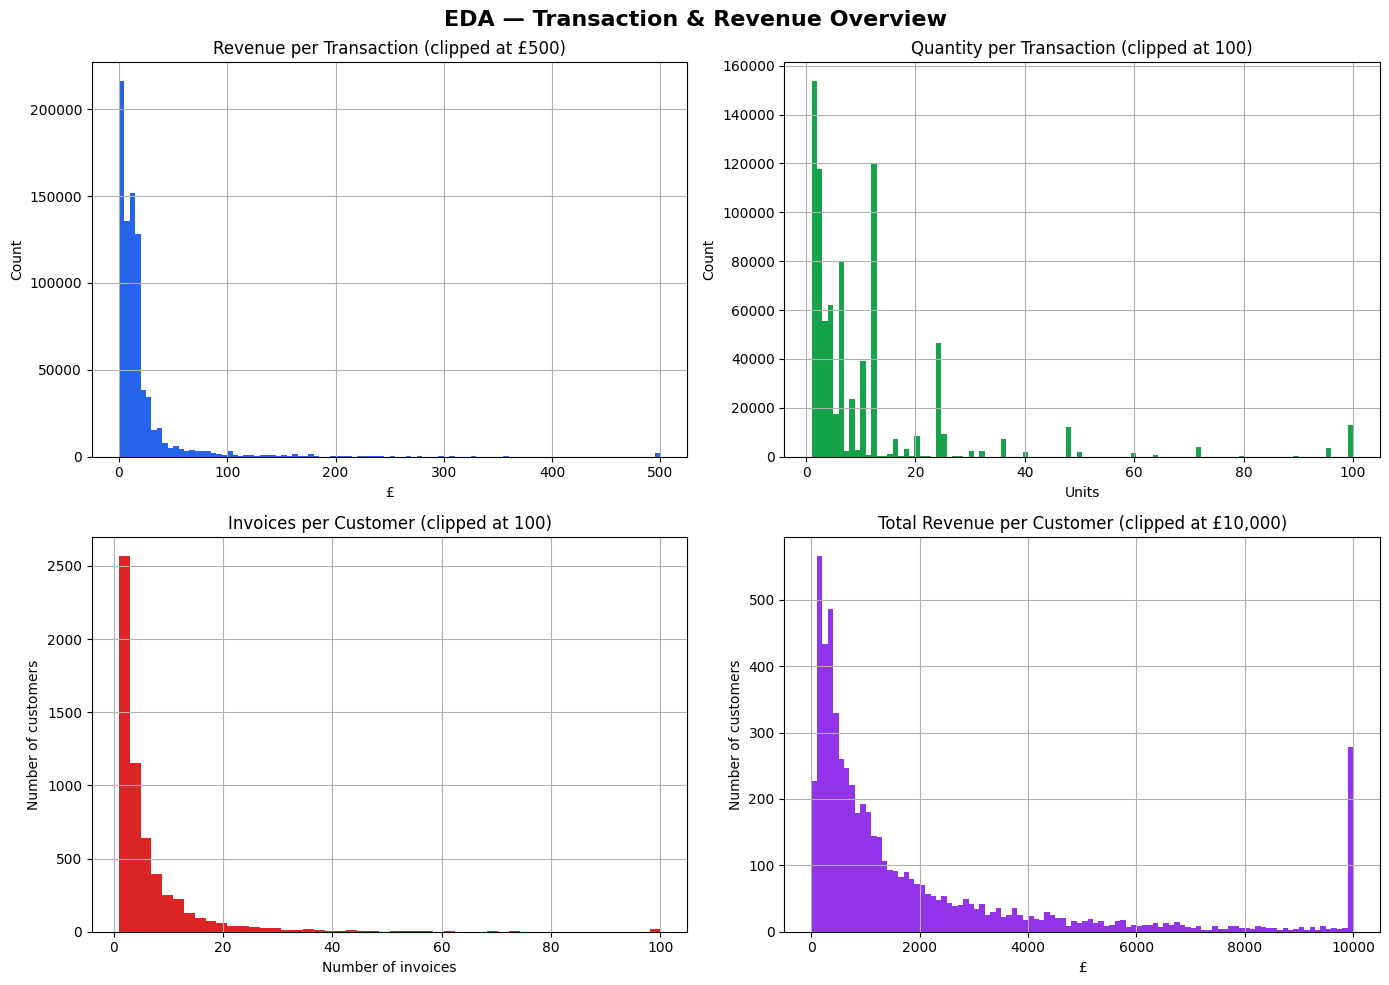

=== REVENUE PER CUSTOMER ===
count      5878.000000
mean       3018.616737
std       14737.731040
min           2.950000
25%         348.762500
50%         898.915000
75%        2307.090000
max      608821.650000
Name: total_price, dtype: float64

Top 20% threshold : £2,967
Top 5% threshold  : £9,535

=== INVOICES PER CUSTOMER ===
count    5878.000000
mean        6.289384
std        13.009406
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: Invoice, dtype: float64


In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EDA - Transaction & Revenue Overview", fontsize=16, fontweight="bold")

# 1. Revenue per transaction (log scale)
ax1 = axes[0, 0]
df_clean["total_price"].clip(upper=500).hist(bins=100, ax=ax1, color="#2563eb", edgecolor="none")
ax1.set_title("Revenue per Transaction (clipped at £500)")
ax1.set_xlabel("£")
ax1.set_ylabel("Count")

# 2. Quantity per transaction (log scale)
ax2 = axes[0, 1]
df_clean["Quantity"].clip(upper=100).hist(bins=100, ax=ax2, color="#16a34a", edgecolor="none")
ax2.set_title("Quantity per Transaction (clipped at 100)")
ax2.set_xlabel("Units")
ax2.set_ylabel("Count")

# 3. Transactions per customer
txn_per_customer = df_clean.groupby("Customer ID")["Invoice"].nunique()
ax3 = axes[1, 0]
txn_per_customer.clip(upper=100).hist(bins=50, ax=ax3, color="#dc2626", edgecolor="none")
ax3.set_title("Invoices per Customer (clipped at 100)")
ax3.set_xlabel("Number of invoices")
ax3.set_ylabel("Number of customers")

# 4. Revenue per customer
revenue_per_customer = df_clean.groupby("Customer ID")["total_price"].sum()
ax4 = axes[1, 1]
revenue_per_customer.clip(upper=10000).hist(bins=100, ax=ax4, color="#9333ea", edgecolor="none")
ax4.set_title("Total Revenue per Customer (clipped at £10,000)")
ax4.set_xlabel("£")
ax4.set_ylabel("Number of customers")

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()

# Key stats
print("=== REVENUE PER CUSTOMER ===")
print(revenue_per_customer.describe())
print(f"\nTop 20% threshold : £{revenue_per_customer.quantile(0.8):,.0f}")
print(f"Top 5% threshold  : £{revenue_per_customer.quantile(0.95):,.0f}")

print("\n=== INVOICES PER CUSTOMER ===")
print(txn_per_customer.describe())

## EDA - Key Findings

### 1. Revenue per Transaction - Extreme Long-tail
Phần lớn giao dịch có giá trị rất nhỏ (tập trung ở £0–50),
nhưng có một số transaction trị giá hàng trăm £.
→ Distribution lệch phải nặng, sẽ cần **log transform** ở bước feature engineering.

### 2. Quantity per Transaction - Spike ở số chẵn
Quantity không phân phối đều - có spike rõ ở 1, 2, 6, 12, 24.
→ Đây là pattern wholesale: khách mua theo **pack/dozen**, không phải lẻ.
Gợi ý dataset này mix cả retail lẫn B2B customers.

### 3. Invoices per Customer - Majority là One-time buyers
- 25th percentile = 1 invoice → **ít nhất 25% customers chỉ mua đúng 1 lần**
- Median = 3 invoices
- Max = 398 invoices → có những loyal customers mua rất thường xuyên
→ Đây là signal mạnh để segment: **one-time vs repeat vs loyal**

### 4. Revenue per Customer - Power law distribution
- Mean = £3,018 nhưng Median chỉ = £899 → bị kéo bởi outliers
- Max = £608,821 → có thể là wholesaler/reseller, không phải retail customer thông thường
- Top 20% customers chi tiêu từ **£2,967 trở lên**
- Top 5% từ **£9,535 trở lên**

→ Phân phối này gần với **Pareto principle**:
  một nhóm nhỏ customers đóng góp phần lớn doanh thu.

### Implications cho Segmentation
| Segment | Đặc điểm gợi ý |
|---|---|
| **High Value** | total_spent > £2,967 (top 20%) |
| **Mid Value** | £899 – £2,967 |
| **Low Value** | < £899 (bottom 50%) |

> Threshold này sẽ được tinh chỉnh ở Phase 5 sau khi có đầy đủ features
> (recency, frequency, product diversity).

In [10]:
## download data

df_clean.to_parquet("clean_transactions.parquet", index=False)